In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from signature_core_py import *
from processes import *

plt.rcParams['figure.dpi'] = 100
generate_new_images = True
np.random.seed(0xDEADBEEF)

In [28]:
def generate_blue_to_red(N):
    # Create a colormap from red to blue
    cmap = plt.get_cmap('viridis')
    colors = [mcolors.rgb2hex(cmap(i)[:3]) for i in np.linspace(0, 1, N)]
    return colors

## Ornstein-Uhlenbeck

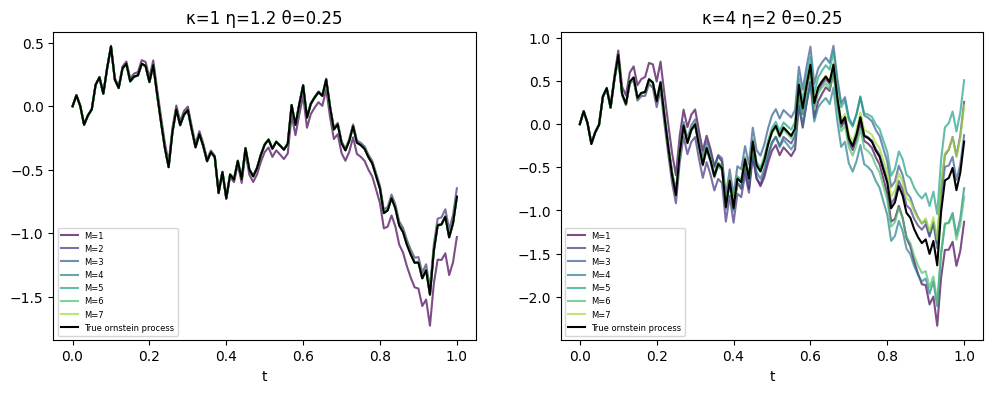

In [29]:
# Parameters
n = 100
max_sig_order = 7
x0 = 0
time_grid = np.arange(start=0, stop=n+1) / n
brownians = generate_brownian(time_grid, 1)
brownian_sig = signature(np.array([time_grid, brownians.flatten()]), max_sig_order)

(ornsteins_1, ornsteins_approx_1) = generate_naive_ornstein_sig(time_grid, brownians, brownian_sig, x0, kappa=1, etha=1.2, theta=0.25, max_sig_order=max_sig_order)
(ornsteins_2, ornsteins_approx_2) = generate_naive_ornstein_sig(time_grid, brownians, brownian_sig, x0, kappa=4, etha=2.0, theta=0.25, max_sig_order=max_sig_order)
cols = generate_blue_to_red(len(ornsteins_approx_1)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# first set of parameters
for i in range(len(ornsteins_approx_1)):
	ax1.plot(time_grid, ornsteins_approx_1[i].transpose(), color=cols[i], label=f"M={i+1}", alpha=0.7, linestyle="-")
ax1.plot(time_grid, ornsteins_1.transpose(), label="True ornstein process", color="black")
ax1.legend(fontsize=6)
ax1.set_xlabel("t")
ax1.set_title("κ=1 η=1.2 θ=0.25")

# and the second one...
for i in range(len(ornsteins_approx_2)):
	ax2.plot(time_grid, ornsteins_approx_2[i].transpose(), color=cols[i], label=f"M={i+1}", alpha=0.7, linestyle="-")
ax2.plot(time_grid, ornsteins_2.transpose(), label="True ornstein process", color="black")
ax2.legend(fontsize=6)
ax2.set_xlabel("t")
ax2.set_title("κ=4 η=2 θ=0.25")

if generate_new_images:
	fig.savefig("outputs/ornstein_approx_naive.png")

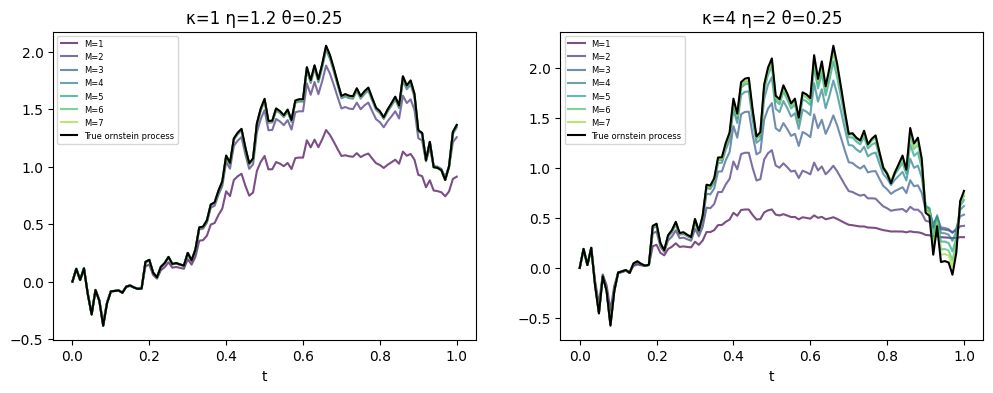

In [30]:
# Parameters
n = 100
max_sig_order = 7
x0 = 0
time_grid = np.arange(start=0, stop=n+1) / n
brownians = generate_brownian(time_grid, 1)
brownian_sig = signature(np.array([time_grid, brownians.flatten()]), max_sig_order)

(ornsteins_1, ornstein_approx_1) = generate_stable_ornstein_sig(time_grid, brownians, brownian_sig, x0, kappa=1, etha=1.2, theta=0.25, max_sig_order=max_sig_order)
(ornsteins_2, ornstein_approx_2) = generate_stable_ornstein_sig(time_grid, brownians, brownian_sig, x0, kappa=4, etha=2, theta=0.25, max_sig_order=max_sig_order)

ols = generate_blue_to_red(len(ornstein_approx_1)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# first set of parameters
for i in range(len(ornstein_approx_1)):
	ax1.plot(time_grid, ornstein_approx_1[i].transpose(), color=cols[i], label=f"M={i+1}", alpha=0.7, linestyle="-")
ax1.plot(time_grid, ornsteins_1.transpose(), label="True ornstein process", color="black")
ax1.legend(fontsize=6)
ax1.set_xlabel("t")
ax1.set_title("κ=1 η=1.2 θ=0.25")

# and the second one...
for i in range(len(ornstein_approx_2)):
	ax2.plot(time_grid, ornstein_approx_2[i].transpose(), color=cols[i], label=f"M={i+1}", alpha=0.7, linestyle="-")
ax2.plot(time_grid, ornsteins_2.transpose(), label="True ornstein process", color="black")
ax2.legend(fontsize=6)
ax2.set_xlabel("t")
ax2.set_title("κ=4 η=2 θ=0.25")

if generate_new_images:
	plt.savefig("outputs/ornstein_approx_stable.png")

## Mean-reverting geometric Brownian motion


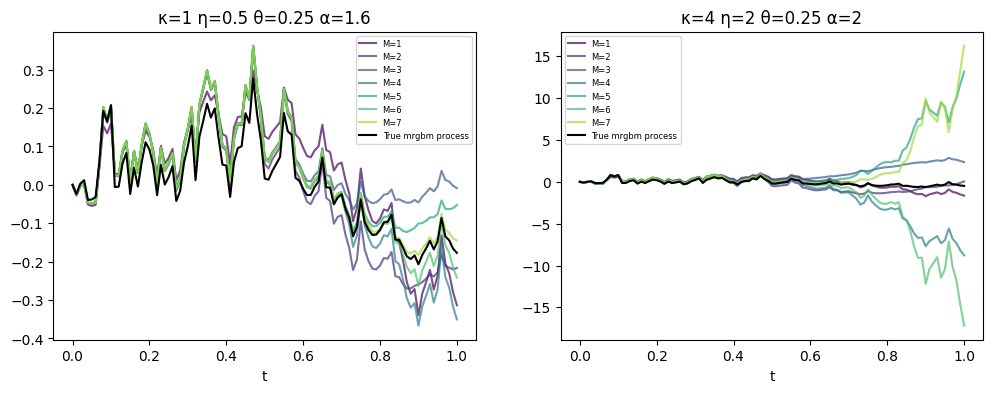

In [31]:
# Parameters
n = 100
max_sig_order = 7
x0 = 0
time_grid = np.arange(start=0, stop=n+1) / n
brownians = generate_brownian(time_grid, 1)
brownian_sig = signature(np.array([time_grid, brownians.flatten()]), max_sig_order)

(mrgbms_1, mrgbm_approx_1) = generate_naive_mrgbm_sig(time_grid, brownians, brownian_sig, x0, kappa=1, etha=0.5, theta=0.25, alpha=1.6, max_sig_order=max_sig_order)
(mrgbms_2, mrgbm_approx_2) = generate_naive_mrgbm_sig(time_grid, brownians, brownian_sig, x0, kappa=4, etha=2, theta=0.25, alpha=2, max_sig_order=max_sig_order)

ols = generate_blue_to_red(len(mrgbm_approx_1)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# first set of parameters
for i in range(len(mrgbm_approx_1)):
	ax1.plot(time_grid, mrgbm_approx_1[i].transpose(), color=cols[i], label=f"M={i+1}", alpha=0.7, linestyle="-")
ax1.plot(time_grid, mrgbms_1.transpose(), label="True mrgbm process", color="black")
ax1.legend(fontsize=6)
ax1.set_xlabel("t")
ax1.set_title("κ=1 η=0.5 θ=0.25 α=1.6")

# and the second one...
for i in range(len(mrgbm_approx_2)):
	ax2.plot(time_grid, mrgbm_approx_2[i].transpose(), color=cols[i], label=f"M={i+1}", alpha=0.7, linestyle="-")
ax2.plot(time_grid, mrgbms_2.transpose(), label="True mrgbm process", color="black")
ax2.legend(fontsize=6)
ax2.set_xlabel("t")
ax2.set_title("κ=4 η=2 θ=0.25 α=2")

if generate_new_images:
	plt.savefig("outputs/mrgbm_approx_naive.png")

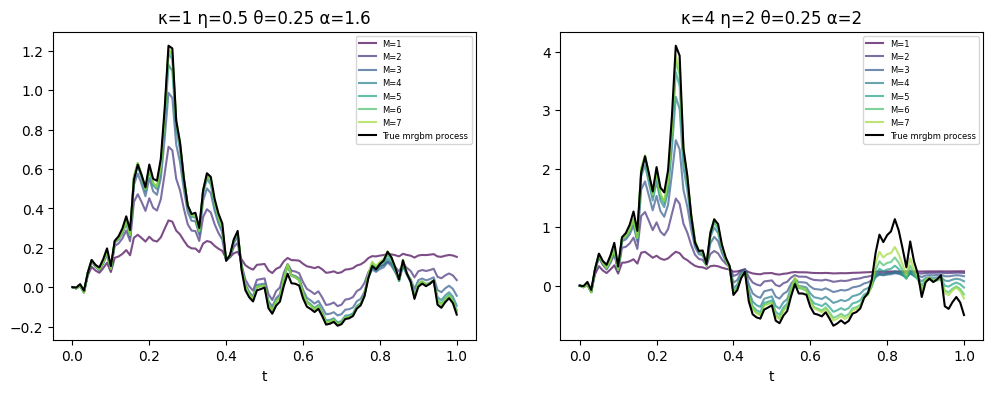

In [32]:
# Parameters
n = 100
max_sig_order = 7
x0 = 0
time_grid = np.arange(start=0, stop=n+1) / n
brownians = generate_brownian(time_grid, 1)
brownian_sig = signature(np.array([time_grid, brownians.flatten()]), max_sig_order)

(mrgbms_1, mrgbm_approx_1) = generate_stable_mrgbm_sig(time_grid, brownians, brownian_sig, x0, kappa=1, etha=0.5, theta=0.25, alpha=1.6, max_sig_order=7)
(mrgbms_2, mrgbm_approx_2) = generate_stable_mrgbm_sig(time_grid, brownians, brownian_sig, x0, kappa=4, etha=2, theta=0.25, alpha=2, max_sig_order=7)

ols = generate_blue_to_red(len(mrgbm_approx_1)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# first set of parameters
for i in range(len(mrgbm_approx_1)):
	ax1.plot(time_grid, mrgbm_approx_1[i].transpose(), color=cols[i], label=f"M={i+1}", alpha=0.7, linestyle="-")
ax1.plot(time_grid, mrgbms_1.transpose(), label="True mrgbm process", color="black")
ax1.legend(fontsize=6)
ax1.set_xlabel("t")
ax1.set_title("κ=1 η=0.5 θ=0.25 α=1.6")

# and the second one...
for i in range(len(mrgbm_approx_2)):
	ax2.plot(time_grid, mrgbm_approx_2[i].transpose(), color=cols[i], label=f"M={i+1}", alpha=0.7, linestyle="-")
ax2.plot(time_grid, mrgbms_2.transpose(), label="True mrgbm process", color="black")
ax2.legend(fontsize=6)
ax2.set_xlabel("t")
ax2.set_title("κ=4 η=2 θ=0.25 α=2")

if generate_new_images:
	plt.savefig("outputs/mrgbm_approx_stable.png")